# Dolly Client Distribution Analysis

This notebook plots the client-side category distributions for the Dolly splits.

- `data_dolly/10` is the legacy Dirichlet split.
- `data_dolly_stratified/10` is the new stratified split that preserves client sizes.

The most useful view for checking the new split is the **normalized proportion plot** and the **deviation-from-global heatmap** for the stratified split. If the clients share the same distribution, those bars should look nearly identical and the heatmap should stay very close to zero.

In [1]:
import json
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = lambda x: f"{x:0.3f}"

REPO_ROOT = Path.cwd()
LEGACY_ROOT = REPO_ROOT / "data_dolly" / "10"
STRATIFIED_ROOT = REPO_ROOT / "data_dolly_stratified" / "10"


In [2]:
def load_split(split_root: Path):
    with open(split_root / "global_training.json") as f:
        global_training = json.load(f)

    categories = sorted({row["category"] for row in global_training})
    global_counts = Counter(row["category"] for row in global_training)
    global_props = pd.Series(global_counts, index=categories, dtype=float) / len(global_training)

    client_rows = []
    client_labels = []
    for client_path in sorted(split_root.glob("local_training_*.json"), key=lambda p: int(p.stem.split("_")[-1])):
        with open(client_path) as f:
            client_records = json.load(f)
        client_counts = Counter(row["category"] for row in client_records)
        client_rows.append(pd.Series(client_counts, index=categories, dtype=float).fillna(0.0))
        client_labels.append(f"client_{client_path.stem.split('_')[-1]}")

    count_df = pd.DataFrame(client_rows, index=client_labels)[categories].astype(int)
    prop_df = count_df.div(count_df.sum(axis=1), axis=0)
    deviation_df = (prop_df - global_props).mul(100.0)
    summary_df = pd.DataFrame(
        {
            "size": count_df.sum(axis=1),
            "max_abs_diff_pp": deviation_df.abs().max(axis=1),
            "mean_abs_diff_pp": deviation_df.abs().mean(axis=1),
        }
    )

    return {
        "root": split_root,
        "categories": categories,
        "count_df": count_df,
        "prop_df": prop_df,
        "global_props": global_props,
        "deviation_df": deviation_df,
        "summary_df": summary_df,
    }


def plot_split(split, title: str):
    categories = split["categories"]
    colors = list(plt.get_cmap("tab20").colors[: len(categories)])

    plot_df = pd.concat(
        [pd.DataFrame([split["global_props"]], index=["global"]), split["prop_df"]],
        axis=0,
    )

    fig, ax = plt.subplots(figsize=(14, 6))
    plot_df.plot(kind="bar", stacked=True, ax=ax, color=colors, width=0.85)
    ax.set_title(f"{title}\nCategory proportions")
    ax.set_ylabel("share of dataset")
    ax.set_xlabel("")
    ax.set_ylim(0, 1.0)
    ax.tick_params(axis="x", rotation=45)

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, title="category", bbox_to_anchor=(1.02, 1.0), loc="upper left")
    fig.tight_layout()
    return fig, ax


In [3]:
legacy = load_split(LEGACY_ROOT)
stratified = load_split(STRATIFIED_ROOT)

comparison = pd.DataFrame(
    {
        "legacy_max_abs_diff_pp": legacy["summary_df"]["max_abs_diff_pp"],
        "stratified_max_abs_diff_pp": stratified["summary_df"]["max_abs_diff_pp"],
        "legacy_mean_abs_diff_pp": legacy["summary_df"]["mean_abs_diff_pp"],
        "stratified_mean_abs_diff_pp": stratified["summary_df"]["mean_abs_diff_pp"],
    }
)

comparison

,legacy_max_abs_diff_pp,stratified_max_abs_diff_pp,legacy_mean_abs_diff_pp,stratified_mean_abs_diff_pp
client_0,20.764,0.022,11.008,0.010
client_1,27.001,0.019,11.113,0.011
client_2,21.069,0.037,9.053,0.018
client_3,31.356,0.037,11.446,0.020
client_4,31.069,0.021,10.373,0.008
client_5,24.563,0.097,10.542,0.073
client_6,43.538,0.031,12.363,0.016
client_7,23.451,0.077,8.758,0.030
client_8,28.357,0.026,11.835,0.012
client_9,22.286,0.087,10.527,0.049


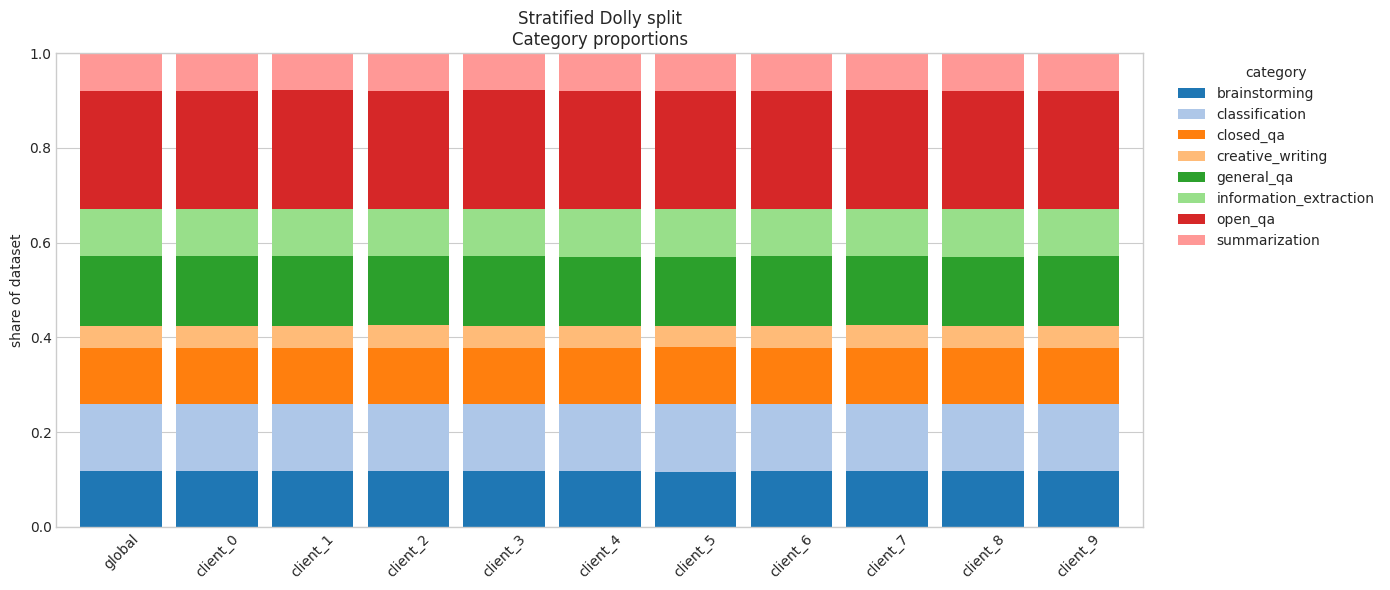

Saved figure to: /home/trieu.vy.tran/FederatedLLM/dolly_stratified_distribution.png


,size,max_abs_diff_pp,mean_abs_diff_pp
client_1,2831,0.019,0.011
client_4,2253,0.021,0.008
client_0,1820,0.022,0.010
client_8,1533,0.026,0.012
client_6,1518,0.031,0.016
client_2,1773,0.037,0.018
client_3,1299,0.037,0.020
client_7,896,0.077,0.030
client_9,443,0.087,0.049
client_5,565,0.097,0.073


In [4]:
fig, ax = plot_split(stratified, "Stratified Dolly split")
png_path = REPO_ROOT / "dolly_stratified_distribution.png"
fig.savefig(png_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved figure to: {png_path}")

stratified["summary_df"].sort_values("max_abs_diff_pp")

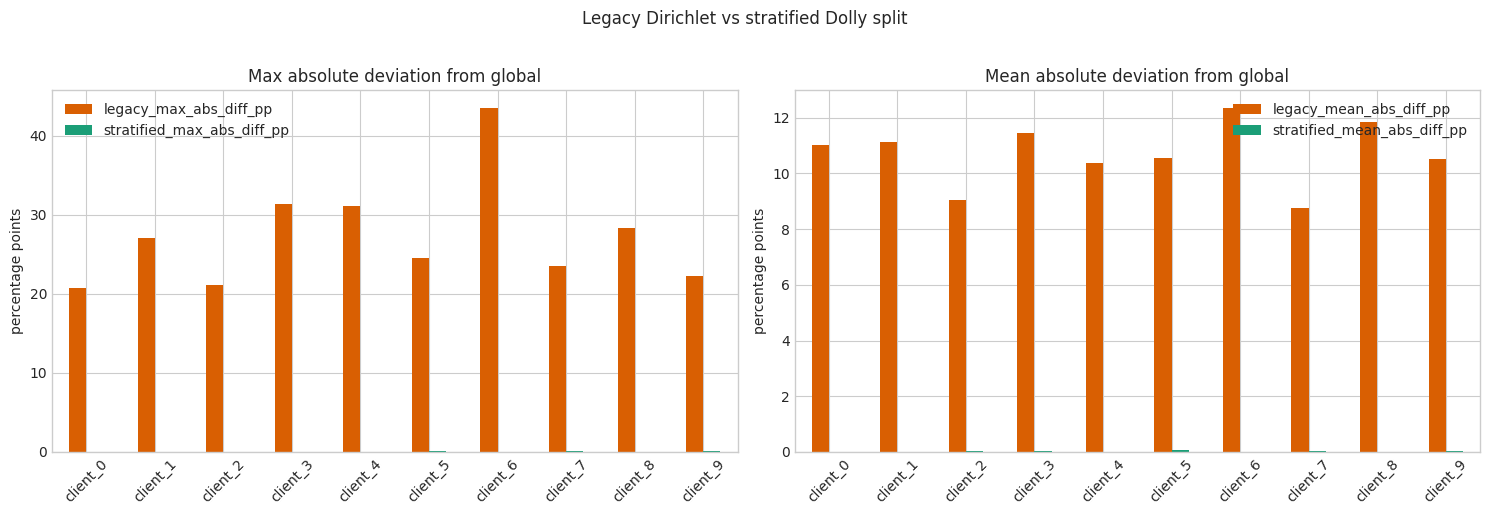

,legacy_max_abs_diff_pp,stratified_max_abs_diff_pp,legacy_mean_abs_diff_pp,stratified_mean_abs_diff_pp
client_0,20.764,0.022,11.008,0.010
client_1,27.001,0.019,11.113,0.011
client_2,21.069,0.037,9.053,0.018
client_3,31.356,0.037,11.446,0.020
client_4,31.069,0.021,10.373,0.008
client_5,24.563,0.097,10.542,0.073
client_6,43.538,0.031,12.363,0.016
client_7,23.451,0.077,8.758,0.030
client_8,28.357,0.026,11.835,0.012
client_9,22.286,0.087,10.527,0.049


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

comparison[["legacy_max_abs_diff_pp", "stratified_max_abs_diff_pp"]].plot(
    kind="bar",
    ax=axes[0],
    color=["#D95F02", "#1B9E77"],
)
axes[0].set_title("Max absolute deviation from global")
axes[0].set_ylabel("percentage points")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=45)

comparison[["legacy_mean_abs_diff_pp", "stratified_mean_abs_diff_pp"]].plot(
    kind="bar",
    ax=axes[1],
    color=["#D95F02", "#1B9E77"],
)
axes[1].set_title("Mean absolute deviation from global")
axes[1].set_ylabel("percentage points")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=45)

fig.suptitle("Legacy Dirichlet vs stratified Dolly split", y=1.02)
fig.tight_layout()
plt.show()

comparison.sort_index()